<a href="https://colab.research.google.com/github/An-Samael/CSV_BigData/blob/main/Avance%20del%20proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ SECCIÓN 1: Librerías cargadas correctamente.
✅ SECCIÓN 2: Dataset cargado exitosamente desde URL.

   ESTRUCTURA Y LIMPIEZA DE DATOS
Dimensiones: 6,234 filas × 12 columnas

✅ Fechas convertidas y columnas de año/mes creadas.

--- Columnas con datos faltantes ---
             Valores Nulos  Porcentaje (%)
director              1969           31.58
cast                   570            9.14
country                476            7.64
year_added              11            0.18
month_added             11            0.18
date_added              11            0.18
rating                  10            0.16


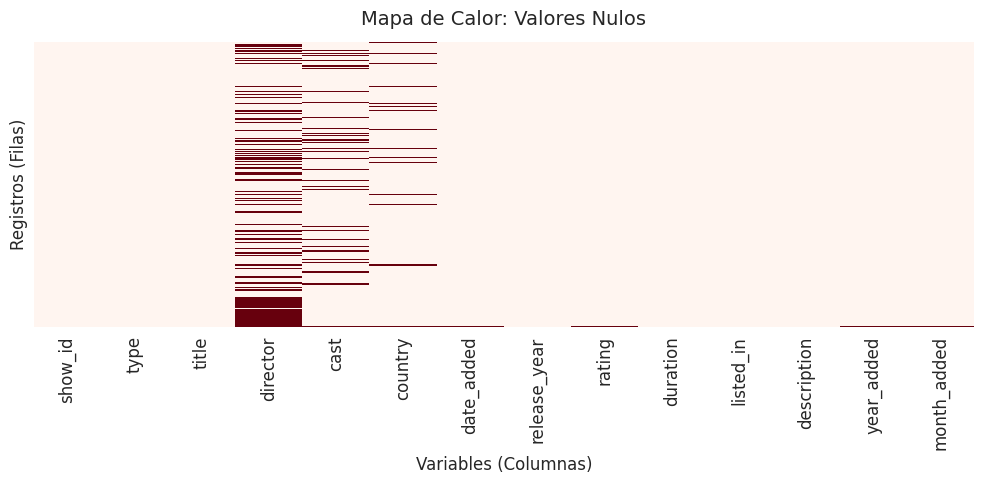


   VISUALIZACIÓN DE RESULTADOS


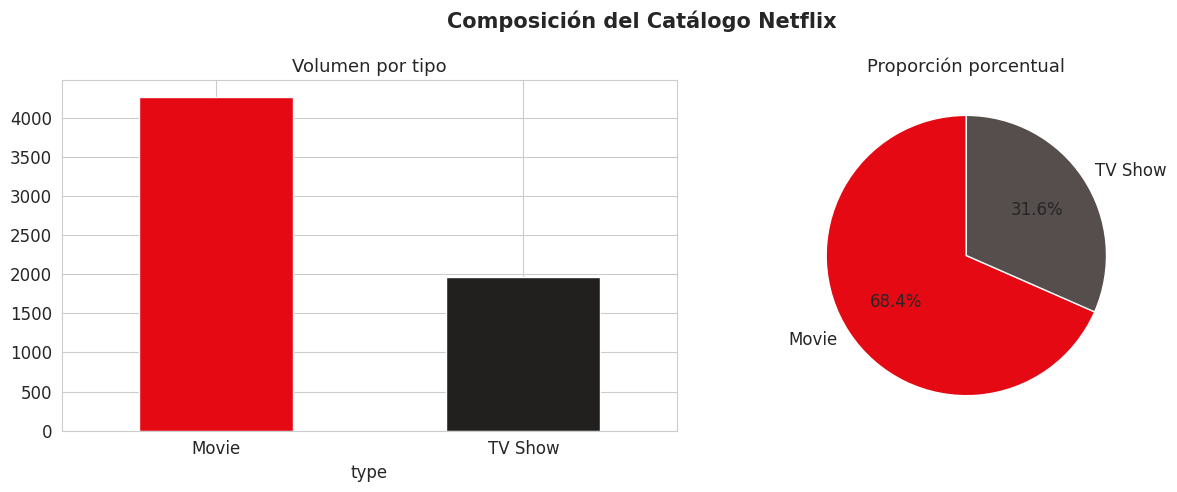

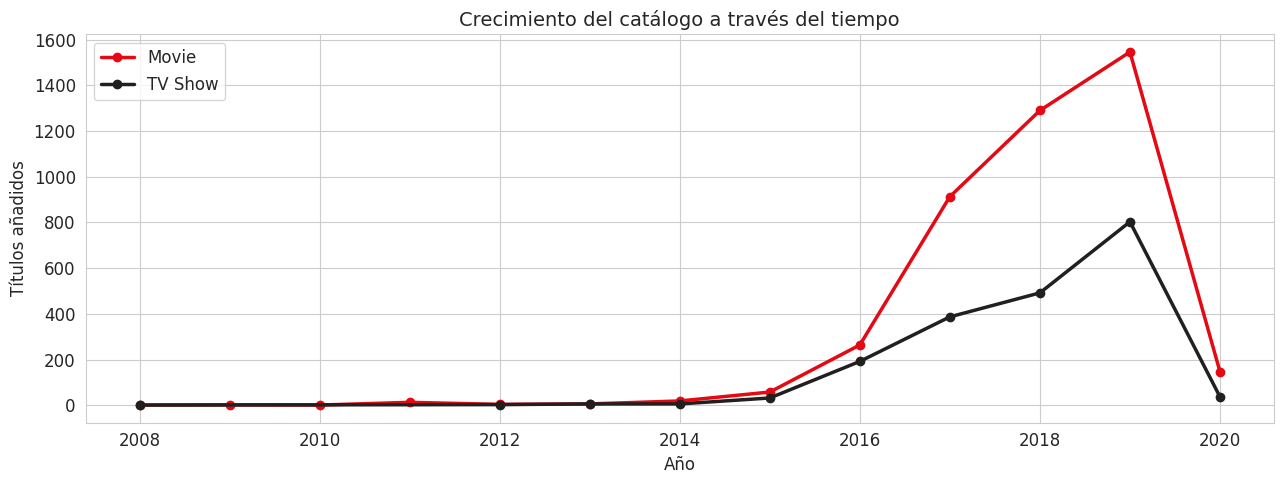

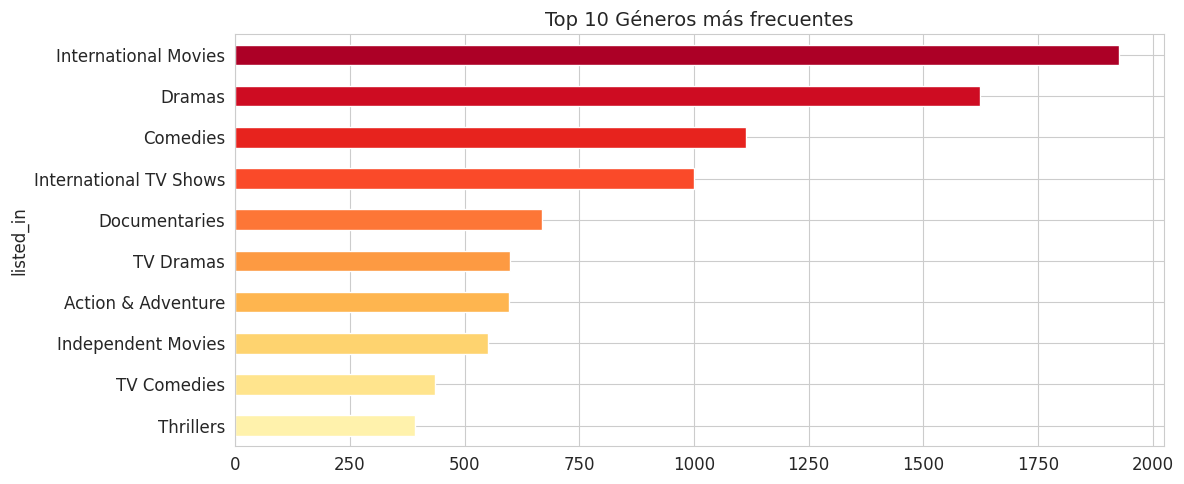

In [ ]:
# =================================================================
# 🎬 ANÁLISIS EXPLORATORIO DE DATOS — CATÁLOGO NETFLIX
# Proyecto: Analítica de Datos para Optimización de Contenido
# =================================================================

# --- SECCIÓN 1: IMPORTACIÓN Y CONFIGURACIÓN ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore') # Ocultar advertencias visuales

# Configuración visual global
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("✅ SECCIÓN 1: Librerías cargadas correctamente.")

# --- SECCIÓN 2: CARGA SEGURA DEL DATASET ---
# URL corregida a un repositorio público altamente estable
URL = "https://raw.githubusercontent.com/prasertcbs/basic-dataset/refs/heads/master/netflix_titles.csv"

try:
    df = pd.read_csv(URL)
    print("✅ SECCIÓN 2: Dataset cargado exitosamente desde URL.")
except Exception as e:
    print(f"❌ Error al cargar la URL: {e}")
    # Respaldo por si falla el internet
    df = pd.read_csv("netflix_titles.csv")
    print("✅ SECCIÓN 2: Dataset cargado desde archivo local.")

# --- SECCIÓN 3: ESTRUCTURA Y TIPOS DE DATOS ---
print("\n" + "="*50)
print("   ESTRUCTURA Y LIMPIEZA DE DATOS")
print("="*50)

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas\n")

# Corrección de formatos de fecha
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
print("✅ Fechas convertidas y columnas de año/mes creadas.")

# --- SECCIÓN 4: DETECCIÓN DE NULOS (CORREGIDO) ---
nulos_abs = df.isnull().sum()
resumen_nulos = pd.DataFrame({
    'Valores Nulos': nulos_abs,
    'Porcentaje (%)': (nulos_abs / len(df) * 100).round(2)
}).sort_values('Porcentaje (%)', ascending=False)

print("\n--- Columnas con datos faltantes ---")
print(resumen_nulos[resumen_nulos['Valores Nulos'] > 0])

# Heatmap optimizado (Sin .T y sin yticklabels)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='Reds',
    ax=ax,
    yticklabels=False # Apagado para evitar saturar la memoria con 8800 etiquetas
)
ax.set_title('Mapa de Calor: Valores Nulos', fontsize=14, pad=12)
ax.set_ylabel('Registros (Filas)')
ax.set_xlabel('Variables (Columnas)')
plt.tight_layout()
plt.show()

# Limpieza rápida para visualizaciones
cols_categoricas = ['director', 'cast', 'country', 'rating']
for col in cols_categoricas:
    df[col] = df[col].fillna('No especificado')
df.dropna(subset=['title'], inplace=True)

# --- SECCIÓN 5: ANÁLISIS VISUAL Y ESTADÍSTICO ---
print("\n" + "="*50)
print("   VISUALIZACIÓN DE RESULTADOS")
print("="*50)

# 1. Proporción de Contenido (Barras y Pastel)
conteo_tipo = df['type'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

conteo_tipo.plot(kind='bar', ax=axes[0], color=['#E50914', '#221F1F'], edgecolor='white')
axes[0].set_title('Volumen por tipo', fontsize=13)
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(conteo_tipo, labels=conteo_tipo.index, autopct='%1.1f%%', startangle=90, colors=['#E50914', '#564D4D'])
axes[1].set_title('Proporción porcentual', fontsize=13)

plt.suptitle('Composición del Catálogo Netflix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Tendencia de crecimiento (Líneas)
tendencia = df.groupby(['year_added', 'type']).size().reset_index(name='cantidad')
tendencia = tendencia[tendencia['year_added'].between(2008, 2021)]

fig, ax = plt.subplots(figsize=(13, 5))
for tipo, color in zip(['Movie', 'TV Show'], ['#E50914', '#221F1F']):
    data = tendencia[tendencia['type'] == tipo]
    ax.plot(data['year_added'], data['cantidad'], marker='o', label=tipo, color=color, linewidth=2.5)

ax.set_title('Crecimiento del catálogo a través del tiempo', fontsize=14)
ax.set_xlabel('Año')
ax.set_ylabel('Títulos añadidos')
ax.legend()
plt.tight_layout()
plt.show()

# 3. Top 10 Géneros (Barras Horizontales)
todos_generos = df['listed_in'].str.split(', ').explode().str.strip().value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
todos_generos.plot(kind='barh', ax=ax, color=sns.color_palette('YlOrRd_r', 10))
ax.invert_yaxis()
ax.set_title('Top 10 Géneros más frecuentes', fontsize=14)
plt.tight_layout()
plt.show()